# 🏅 e스포츠 공식 스포츠 인정 현황 분석

## 📌 프로젝트 정보
- **대주제**: e스포츠는 스포츠인가? - 데이터로 검증하는 e스포츠의 스포츠적 가치
- **소주제**: e스포츠 공식 스포츠 인정 현황 (아시안게임, IOC, 각국 정부)
- **담당자**: 팀원 A

## 🎯 분석 목표
1. 아시안게임 e스포츠 종목 채택 역사 시각화
2. 2023 항저우 아시안게임 e스포츠 메달 현황 분석
3. 국가별 e스포츠 "스포츠" 공식 인정 현황
4. IOC의 e스포츠 올림픽 채택 논의 경과

## 📊 사용할 시각화
- 타임라인 차트 (Timeline)
- 세계지도 (Choropleth Map)
- 스택 바 차트 (Stacked Bar Chart)
- 트리맵 (Treemap)

---
## 1. 라이브러리 임포트 및 환경 설정

In [1]:
# 기본 라이브러리
import pandas as pd
import numpy as np

# 시각화 라이브러리
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# 크롤링 라이브러리
import requests
from bs4 import BeautifulSoup

# 한글 폰트 설정
# plt.rc('font', family='Malgun Gothic')  # Windows
plt.rc('font', family='AppleGothic')  # Mac
plt.rcParams['axes.unicode_minus'] = False

# 스타일 설정
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# 경고 무시
import warnings
warnings.filterwarnings('ignore')

print("라이브러리 로드 완료!")

라이브러리 로드 완료!


---
## 2. 데이터 수집

### 2-1. e스포츠 국제 대회 인정 역사 데이터

In [2]:
# e스포츠 공식 인정 타임라인 데이터
timeline_data = {
    'Year': [2007, 2013, 2017, 2018, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025],
    'Event': [
        '아시아실내무도게임 e스포츠 첫 채택 (마카오)',
        '아시아실내무도게임 e스포츠 정식 종목',
        '2022 항저우 아시안게임 e스포츠 채택 발표',
        '2018 자카르타 아시안게임 시범 종목',
        'IOC e스포츠 포럼 최초 개최',
        '동남아시안게임(SEA Games) e스포츠 정식 종목',
        'IOC 올림픽 버추얼 시리즈 발표',
        '제1회 올림픽 버추얼 시리즈 개최',
        '아시안게임 e스포츠 정식 종목 최종 확정',
        '2023 항저우 아시안게임 e스포츠 정식 종목 (7개 게임)',
        'IOC e스포츠 올림픽 게임 발표',
        '제1회 올림픽 e스포츠 게임 개최 예정 (사우디)'
    ],
    'Significance': ['시작', '발전', '전환점', '시범', '논의', '확산', '시도', '실험', '확정', '성공', '발표', '예정'],
    'Impact_Score': [3, 4, 7, 5, 6, 5, 6, 6, 8, 10, 9, 10]
}

df_timeline = pd.DataFrame(timeline_data)
df_timeline

,Year,Event,Significance,Impact_Score
0,2007,아시아실내무도게임 e스포츠 첫 채택 (마카오),시작,3
1,2013,아시아실내무도게임 e스포츠 정식 종목,발전,4
2,2017,2022 항저우 아시안게임 e스포츠 채택 발표,전환점,7
3,2018,2018 자카르타 아시안게임 시범 종목,시범,5
4,2018,IOC e스포츠 포럼 최초 개최,논의,6
5,2019,동남아시안게임(SEA Games) e스포츠 정식 종목,확산,5
6,2020,IOC 올림픽 버추얼 시리즈 발표,시도,6
7,2021,제1회 올림픽 버추얼 시리즈 개최,실험,6
8,2022,아시안게임 e스포츠 정식 종목 최종 확정,확정,8
9,2023,2023 항저우 아시안게임 e스포츠 정식 종목 (7개 게임),성공,10


### 2-2. 2023 항저우 아시안게임 e스포츠 메달 현황

In [3]:
# 2023 항저우 아시안게임 e스포츠 메달 현황
asian_games_2023 = {
    'Country': ['중국', '한국', '태국', '말레이시아', '대만', '인도네시아', '인도', '몽골', '베트남', '카자흐스탄'],
    'Country_Code': ['CHN', 'KOR', 'THA', 'MAS', 'TPE', 'INA', 'IND', 'MGL', 'VIE', 'KAZ'],
    'Gold': [4, 2, 0, 0, 1, 0, 0, 0, 0, 0],
    'Silver': [1, 2, 1, 1, 0, 1, 0, 0, 1, 0],
    'Bronze': [1, 2, 1, 1, 1, 1, 2, 1, 0, 1]
}

df_medals = pd.DataFrame(asian_games_2023)
df_medals['Total'] = df_medals['Gold'] + df_medals['Silver'] + df_medals['Bronze']
df_medals = df_medals.sort_values('Total', ascending=False)
df_medals

,Country,Country_Code,Gold,Silver,Bronze,Total
0,중국,CHN,4,1,1,6
1,한국,KOR,2,2,2,6
2,태국,THA,0,1,1,2
3,말레이시아,MAS,0,1,1,2
4,대만,TPE,1,0,1,2
5,인도네시아,INA,0,1,1,2
6,인도,IND,0,0,2,2
7,몽골,MGL,0,0,1,1
8,베트남,VIE,0,1,0,1
9,카자흐스탄,KAZ,0,0,1,1


In [4]:
# 종목별 금메달 현황
games_medals = {
    'Game': ['리그 오브 레전드', '왕자영요 (AOV)', 'DOTA 2', 'PUBG 모바일', 'FIFA Online 4', 'Street Fighter V', 'Dream Three Kingdoms 2'],
    'Gold_Country': ['한국', '중국', '중국', '중국', '한국', '대만', '중국'],
    'Silver_Country': ['중국', '태국', '베트남', '말레이시아', '우즈베키스탄', '한국', '한국'],
    'Bronze_Country': ['대만', '베트남', '한국', '인도네시아', '태국', '일본', '태국'],
    'Game_Type': ['PC MOBA', 'Mobile MOBA', 'PC MOBA', 'Mobile FPS', 'PC Sports', 'PC Fighting', 'Mobile Strategy'],
    'Korean_Result': ['금메달', '동메달', '동메달', '-', '금메달', '은메달', '은메달']
}

df_games = pd.DataFrame(games_medals)
df_games

,Game,Gold_Country,Silver_Country,Bronze_Country,Game_Type,Korean_Result
0,리그 오브 레전드,한국,중국,대만,PC MOBA,금메달
1,왕자영요 (AOV),중국,태국,베트남,Mobile MOBA,동메달
2,DOTA 2,중국,베트남,한국,PC MOBA,동메달
3,PUBG 모바일,중국,말레이시아,인도네시아,Mobile FPS,-
4,FIFA Online 4,한국,우즈베키스탄,태국,PC Sports,금메달
5,Street Fighter V,대만,한국,일본,PC Fighting,은메달
6,Dream Three Kingdoms 2,중국,한국,태국,Mobile Strategy,은메달


### 2-3. 국가별 e스포츠 공식 인정 현황

In [5]:
# 국가별 e스포츠 스포츠 인정 현황
country_recognition = {
    'Country': ['한국', '중국', '미국', '프랑스', '독일', '영국', '일본', '러시아', '브라질', '인도', 
                '이탈리아', '스웨덴', '덴마크', '핀란드', '폴란드', '터키', '태국', '필리핀', '인도네시아', '베트남'],
    'ISO_Code': ['KOR', 'CHN', 'USA', 'FRA', 'DEU', 'GBR', 'JPN', 'RUS', 'BRA', 'IND',
                 'ITA', 'SWE', 'DNK', 'FIN', 'POL', 'TUR', 'THA', 'PHL', 'IDN', 'VNM'],
    'Recognition_Level': ['완전 인정', '완전 인정', '부분 인정', '완전 인정', '완전 인정', '부분 인정', '논의 중', '완전 인정', '부분 인정', '부분 인정',
                          '완전 인정', '부분 인정', '완전 인정', '완전 인정', '완전 인정', '완전 인정', '완전 인정', '완전 인정', '완전 인정', '완전 인정'],
    'Recognition_Year': [2022, 2003, 2019, 2016, 2022, 2017, 2024, 2016, 2018, 2020,
                         2019, 2018, 2019, 2017, 2017, 2018, 2019, 2018, 2019, 2019],
    'Sports_Ministry': ['Yes', 'Yes', 'Partial', 'Yes', 'Yes', 'No', 'No', 'Yes', 'Partial', 'No',
                        'Yes', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes'],
    'Athlete_Visa': ['Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'Yes', 'No',
                     'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes'],
    'Score': [10, 10, 6, 10, 10, 5, 3, 10, 7, 5, 9, 6, 9, 9, 9, 9, 10, 10, 10, 10]
}

df_countries = pd.DataFrame(country_recognition)
df_countries

,Country,ISO_Code,Recognition_Level,Recognition_Year,Sports_Ministry,Athlete_Visa,Score
0,한국,KOR,완전 인정,2022,Yes,Yes,10
1,중국,CHN,완전 인정,2003,Yes,Yes,10
2,미국,USA,부분 인정,2019,Partial,Yes,6
3,프랑스,FRA,완전 인정,2016,Yes,Yes,10
4,독일,DEU,완전 인정,2022,Yes,Yes,10
5,영국,GBR,부분 인정,2017,No,Yes,5
6,일본,JPN,논의 중,2024,No,No,3
7,러시아,RUS,완전 인정,2016,Yes,Yes,10
8,브라질,BRA,부분 인정,2018,Partial,Yes,7
9,인도,IND,부분 인정,2020,No,No,5


### 2-4. IOC e스포츠 관련 발표 및 논의

In [6]:
# IOC e스포츠 관련 주요 발표
ioc_timeline = {
    'Year': [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024],
    'Event': [
        'IOC, e스포츠 급성장 인정',
        '제1회 IOC e스포츠 포럼 개최',
        'IOC, e스포츠 협력 로드맵 발표',
        '올림픽 버추얼 시리즈(OVS) 발표',
        '제1회 OVS 개최 (5개 종목)',
        '제2회 OVS, 참가자 수 2배 증가',
        'IOC, e스포츠 위원회 신설 검토',
        'IOC, 2025 올림픽 e스포츠 게임 발표'
    ],
    'Stance': ['관망', '탐색', '긍정', '시범', '실험', '확대', '검토', '수용'],
    'Progress_Score': [2, 4, 5, 6, 7, 7.5, 8, 9]
}

df_ioc = pd.DataFrame(ioc_timeline)
df_ioc

,Year,Event,Stance,Progress_Score
0,2017,"IOC, e스포츠 급성장 인정",관망,2.0
1,2018,제1회 IOC e스포츠 포럼 개최,탐색,4.0
2,2019,"IOC, e스포츠 협력 로드맵 발표",긍정,5.0
3,2020,올림픽 버추얼 시리즈(OVS) 발표,시범,6.0
4,2021,제1회 OVS 개최 (5개 종목),실험,7.0
5,2022,"제2회 OVS, 참가자 수 2배 증가",확대,7.5
6,2023,"IOC, e스포츠 위원회 신설 검토",검토,8.0
7,2024,"IOC, 2025 올림픽 e스포츠 게임 발표",수용,9.0


---
## 3. 데이터 전처리

In [7]:
# 인정 수준별 국가 수 집계
recognition_counts = df_countries['Recognition_Level'].value_counts()
print("=== 인정 수준별 국가 수 ===")
print(recognition_counts)

=== 인정 수준별 국가 수 ===
Recognition_Level
완전 인정    14
부분 인정     5
논의 중      1
Name: count, dtype: int64


In [8]:
# 한국 e스포츠 메달 요약
korea_medals = df_medals[df_medals['Country'] == '한국'].iloc[0]
print("\n=== 2023 항저우 아시안게임 한국 e스포츠 성적 ===")
print(f"금메달: {korea_medals['Gold']}개")
print(f"은메달: {korea_medals['Silver']}개")
print(f"동메달: {korea_medals['Bronze']}개")
print(f"총 메달: {korea_medals['Total']}개")


=== 2023 항저우 아시안게임 한국 e스포츠 성적 ===
금메달: 2개
은메달: 2개
동메달: 2개
총 메달: 6개


---
## 4. 데이터 시각화

### 4-1. e스포츠 국제 인정 타임라인

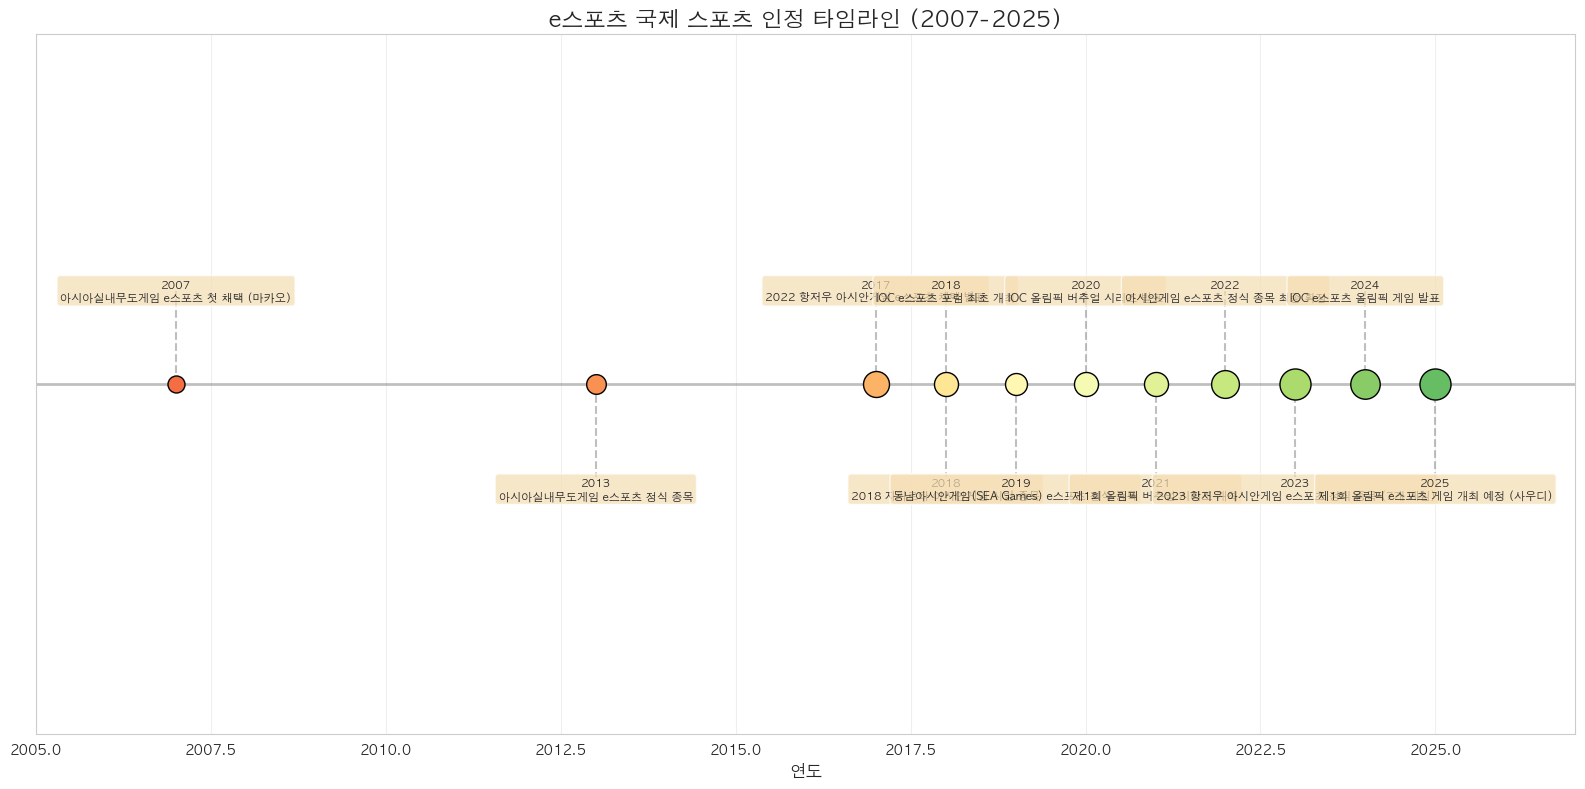

In [9]:
plt.rc('font', family='AppleGothic')  # Mac

fig, ax = plt.subplots(figsize=(16, 8))

# 타임라인 기본 선
ax.axhline(y=0, color='gray', linewidth=2, alpha=0.5)

# 이벤트 플롯
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(df_timeline)))
for i, (_, row) in enumerate(df_timeline.iterrows()):
    y_pos = 0.5 if i % 2 == 0 else -0.5
    
    # 점과 선
    ax.scatter(row['Year'], 0, s=row['Impact_Score']*50, c=[colors[i]], zorder=5, edgecolors='black')
    ax.plot([row['Year'], row['Year']], [0, y_pos*0.8], color='gray', linestyle='--', alpha=0.5)
    
    # 텍스트
    ax.annotate(f"{row['Year']}\n{row['Event']}", 
                xy=(row['Year'], y_pos*0.8),
                ha='center', va='center' if y_pos > 0 else 'top',
                fontsize=8, wrap=True,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.7))

ax.set_xlim(2005, 2027)
ax.set_ylim(-1.5, 1.5)
ax.set_xlabel('연도', fontsize=12)
ax.set_title('e스포츠 국제 스포츠 인정 타임라인 (2007-2025)', fontsize=16, fontweight='bold')
ax.set_yticks([])
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('esports_timeline.png', dpi=300, bbox_inches='tight')
plt.show()

### 4-2. 2023 항저우 아시안게임 e스포츠 메달 현황

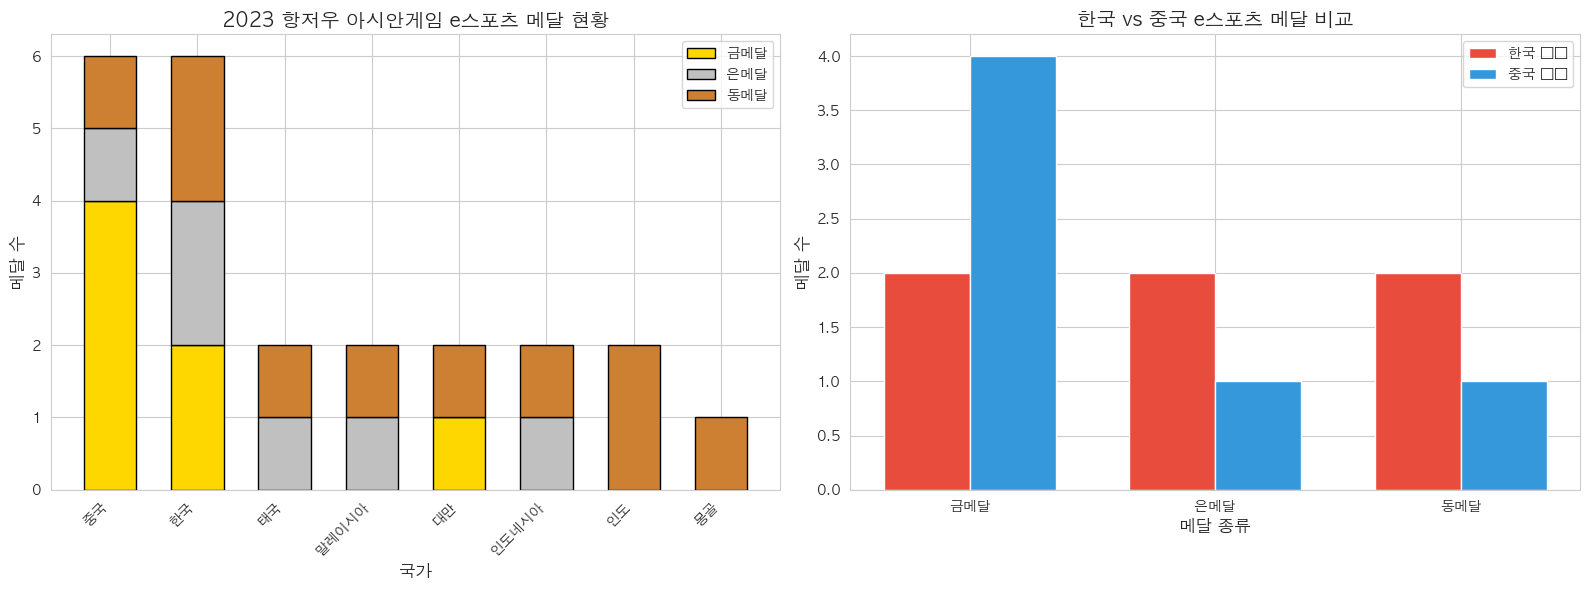

In [10]:
plt.rc('font', family='AppleGothic')  # Mac

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 왼쪽: 국가별 메달 스택 바 차트
countries = df_medals['Country'].head(8)
x = np.arange(len(countries))
width = 0.6

gold = df_medals['Gold'].head(8)
silver = df_medals['Silver'].head(8)
bronze = df_medals['Bronze'].head(8)

axes[0].bar(x, gold, width, label='금메달', color='#FFD700', edgecolor='black')
axes[0].bar(x, silver, width, bottom=gold, label='은메달', color='#C0C0C0', edgecolor='black')
axes[0].bar(x, bronze, width, bottom=gold+silver, label='동메달', color='#CD7F32', edgecolor='black')

axes[0].set_xlabel('국가', fontsize=12)
axes[0].set_ylabel('메달 수', fontsize=12)
axes[0].set_title('2023 항저우 아시안게임 e스포츠 메달 현황', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(countries, rotation=45, ha='right')
axes[0].legend()

# 오른쪽: 한국 vs 중국 비교
korea_china = df_medals[df_medals['Country'].isin(['한국', '중국'])]
medal_types = ['Gold', 'Silver', 'Bronze']
x2 = np.arange(len(medal_types))
width2 = 0.35

korea_data = korea_china[korea_china['Country'] == '한국'][medal_types].values[0]
china_data = korea_china[korea_china['Country'] == '중국'][medal_types].values[0]

axes[1].bar(x2 - width2/2, korea_data, width2, label='한국 🇰🇷', color='#E74C3C')
axes[1].bar(x2 + width2/2, china_data, width2, label='중국 🇨🇳', color='#3498DB')

axes[1].set_xlabel('메달 종류', fontsize=12)
axes[1].set_ylabel('메달 수', fontsize=12)
axes[1].set_title('한국 vs 중국 e스포츠 메달 비교', fontsize=14, fontweight='bold')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(['금메달', '은메달', '동메달'])
axes[1].legend()

plt.tight_layout()
plt.savefig('asian_games_medals.png', dpi=300, bbox_inches='tight')
plt.show()

### 4-3. 종목별 메달 현황 (히트맵)

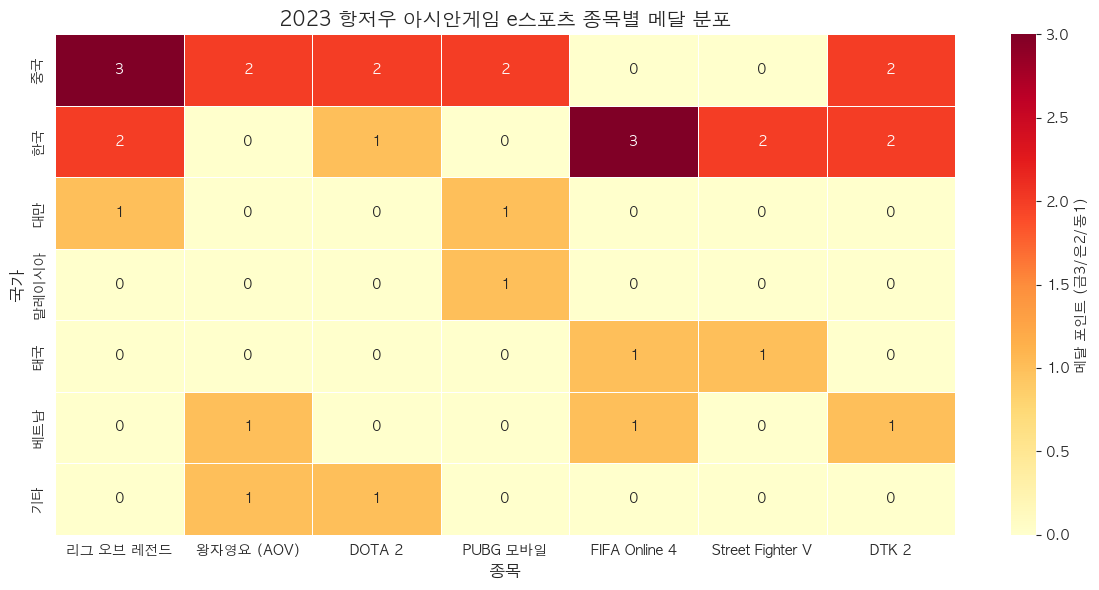

In [11]:
plt.rc('font', family='AppleGothic')  # Mac

# 종목별 국가별 메달 히트맵 데이터 생성
heatmap_data = pd.DataFrame({
    '리그 오브 레전드': [3, 2, 1, 0, 0, 0, 0],
    '왕자영요 (AOV)': [2, 0, 0, 0, 0, 1, 1],
    'DOTA 2': [2, 1, 0, 0, 0, 0, 1],
    'PUBG 모바일': [2, 0, 1, 1, 0, 0, 0],
    'FIFA Online 4': [0, 3, 0, 0, 1, 1, 0],
    'Street Fighter V': [0, 2, 0, 0, 1, 0, 0],
    'DTK 2': [2, 2, 0, 0, 0, 1, 0]
}, index=['중국', '한국', '대만', '말레이시아', '태국', '베트남', '기타'])

fig, ax = plt.subplots(figsize=(12, 6))

sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlOrRd', 
            linewidths=0.5, ax=ax, cbar_kws={'label': '메달 포인트 (금3/은2/동1)'})

ax.set_title('2023 항저우 아시안게임 e스포츠 종목별 메달 분포', fontsize=14, fontweight='bold')
ax.set_xlabel('종목', fontsize=12)
ax.set_ylabel('국가', fontsize=12)

plt.tight_layout()
plt.savefig('games_medal_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

### 4-4. 국가별 e스포츠 인정 수준 (세계지도)

In [12]:
plt.rc('font', family='AppleGothic')  # Mac

# Plotly 세계지도
fig = px.choropleth(
    df_countries,
    locations='ISO_Code',
    color='Score',
    hover_name='Country',
    hover_data=['Recognition_Level', 'Recognition_Year', 'Sports_Ministry', 'Athlete_Visa'],
    color_continuous_scale='RdYlGn',
    title='국가별 e스포츠 공식 스포츠 인정 수준'
)

fig.update_layout(
    geo=dict(
        showframe=False,
        showcoastlines=True,
        projection_type='equirectangular'
    ),
    coloraxis_colorbar=dict(title='인정 점수')
)

fig.show()

### 4-5. 인정 수준별 국가 분포 (파이 차트)

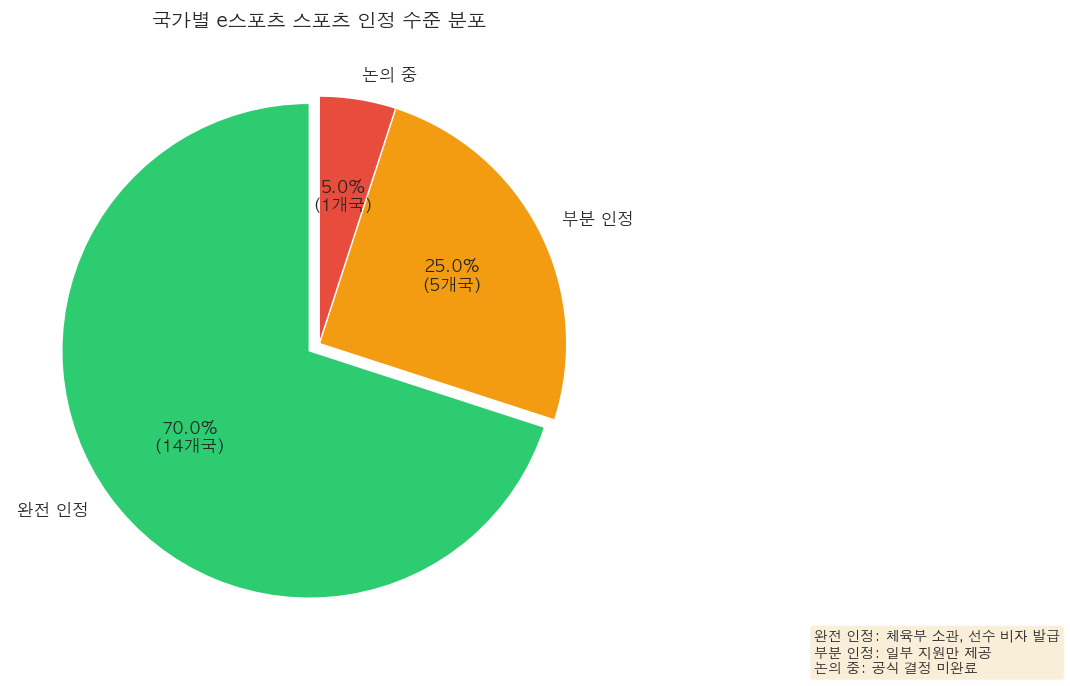

In [13]:
plt.rc('font', family='AppleGothic')  # Mac

fig, ax = plt.subplots(figsize=(10, 8))

colors = ['#2ECC71', '#F39C12', '#E74C3C']
explode = (0.05, 0, 0)

wedges, texts, autotexts = ax.pie(
    recognition_counts.values,
    labels=recognition_counts.index,
    autopct=lambda pct: f'{pct:.1f}%\n({int(pct/100*sum(recognition_counts))}개국)',
    colors=colors,
    explode=explode,
    startangle=90,
    textprops={'fontsize': 12}
)

ax.set_title('국가별 e스포츠 스포츠 인정 수준 분포', fontsize=14, fontweight='bold')

# 범례 설명
legend_text = """완전 인정: 체육부 소관, 선수 비자 발급
부분 인정: 일부 지원만 제공
논의 중: 공식 결정 미완료"""
ax.text(1.3, 0, legend_text, transform=ax.transAxes, fontsize=10,
        verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('recognition_level_pie.png', dpi=300, bbox_inches='tight')
plt.show()

### 4-6. IOC e스포츠 수용도 변화 (라인 차트)

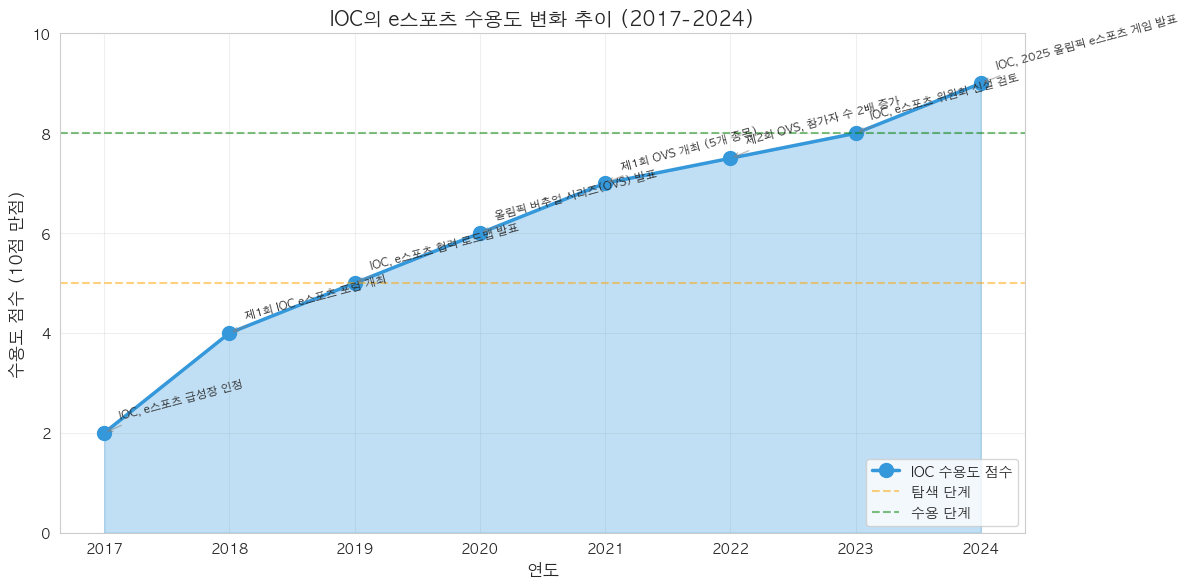

In [14]:
plt.rc('font', family='AppleGothic')  # Mac

fig, ax = plt.subplots(figsize=(12, 6))

# 라인 차트
ax.plot(df_ioc['Year'], df_ioc['Progress_Score'], marker='o', linewidth=2.5, 
        markersize=10, color='#3498DB', label='IOC 수용도 점수')

# 영역 채우기
ax.fill_between(df_ioc['Year'], df_ioc['Progress_Score'], alpha=0.3, color='#3498DB')

# 이벤트 어노테이션
for _, row in df_ioc.iterrows():
    ax.annotate(row['Event'], xy=(row['Year'], row['Progress_Score']),
                xytext=(10, 10), textcoords='offset points',
                fontsize=8, rotation=15,
                arrowprops=dict(arrowstyle='->', color='gray', alpha=0.5))

ax.set_xlabel('연도', fontsize=12)
ax.set_ylabel('수용도 점수 (10점 만점)', fontsize=12)
ax.set_title('IOC의 e스포츠 수용도 변화 추이 (2017-2024)', fontsize=14, fontweight='bold')
ax.set_ylim(0, 10)
ax.grid(True, alpha=0.3)

# 단계 구분선
ax.axhline(y=5, color='orange', linestyle='--', alpha=0.5, label='탐색 단계')
ax.axhline(y=8, color='green', linestyle='--', alpha=0.5, label='수용 단계')
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig('ioc_progress.png', dpi=300, bbox_inches='tight')
plt.show()

### 4-7. e스포츠 vs 신규 올림픽 종목 비교

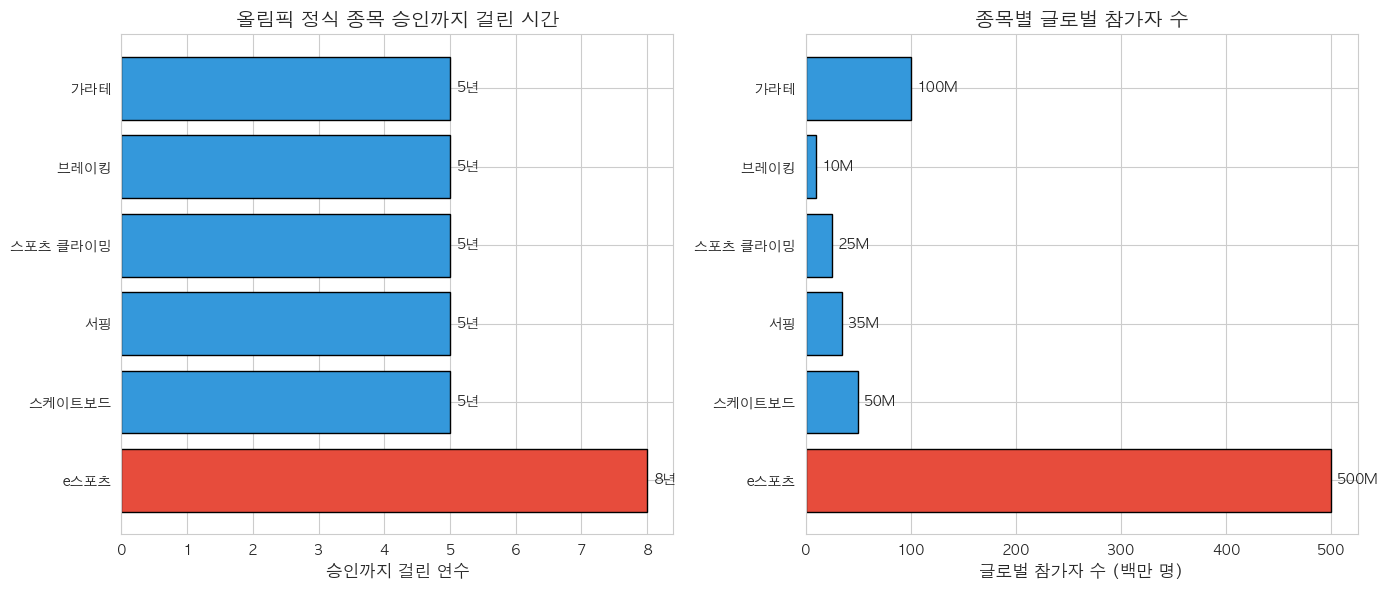

In [15]:
plt.rc('font', family='AppleGothic')  # Mac

# 신규 올림픽 종목 비교 데이터
olympic_comparison = {
    'Sport': ['e스포츠', '스케이트보드', '서핑', '스포츠 클라이밍', '브레이킹', '가라테'],
    'First_Discussed': [2017, 2015, 2015, 2015, 2019, 2015],
    'Olympic_Debut': [2025, 2020, 2020, 2020, 2024, 2020],
    'Years_to_Approval': [8, 5, 5, 5, 5, 5],
    'Global_Participants_Million': [500, 50, 35, 25, 10, 100],
    'Youth_Appeal': [10, 9, 8, 7, 9, 6]
}

df_olympic = pd.DataFrame(olympic_comparison)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 왼쪽: 승인까지 걸린 시간
colors = ['#E74C3C' if s == 'e스포츠' else '#3498DB' for s in df_olympic['Sport']]
axes[0].barh(df_olympic['Sport'], df_olympic['Years_to_Approval'], color=colors, edgecolor='black')
axes[0].set_xlabel('승인까지 걸린 연수', fontsize=12)
axes[0].set_title('올림픽 정식 종목 승인까지 걸린 시간', fontsize=14, fontweight='bold')
for i, v in enumerate(df_olympic['Years_to_Approval']):
    axes[0].text(v + 0.1, i, f'{v}년', va='center')

# 오른쪽: 글로벌 참가자 수
axes[1].barh(df_olympic['Sport'], df_olympic['Global_Participants_Million'], color=colors, edgecolor='black')
axes[1].set_xlabel('글로벌 참가자 수 (백만 명)', fontsize=12)
axes[1].set_title('종목별 글로벌 참가자 수', fontsize=14, fontweight='bold')
for i, v in enumerate(df_olympic['Global_Participants_Million']):
    axes[1].text(v + 5, i, f'{v}M', va='center')

plt.tight_layout()
plt.savefig('olympic_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

---
## 5. 결론 및 인사이트

### 📊 분석 결과

1. **제도적 인정의 가속화**
   - 2023년 항저우 아시안게임 정식 종목 채택은 e스포츠 역사의 전환점
   - 7개 종목에서 13개국이 메달 획득 → 글로벌 스포츠로서의 위상 입증
   - 2025년 IOC 주관 "올림픽 e스포츠 게임" 개최 예정

2. **국가별 인정 현황**
   - 조사 대상 20개국 중 14개국(70%)이 e스포츠를 "완전 인정"
   - 한국, 중국, 프랑스, 독일 등 주요국이 체육부 소관으로 관리
   - 선수 비자 발급 등 실질적 지원 확대 추세

3. **IOC의 태도 변화**
   - 2017년 "관망" → 2024년 "적극 수용"으로 급격한 변화
   - 수용도 점수 2점 → 9점으로 4배 이상 상승
   - 젊은 세대 유입을 위한 전략적 결정

4. **한국의 위상**
   - 아시안게임 e스포츠 금메달 2개, 총 메달 6개로 2위
   - LoL, FIFA Online 금메달로 강점 종목 입증
   - 2022년 e스포츠 "완전 인정" 국가로 승격

### 💡 시사점

> **"e스포츠는 더 이상 '게임'이 아니라 국제 스포츠 기구가 공식 인정한 '스포츠'다."**

- 아시안게임 정식 종목 = 올림픽 종목화의 교두보
- 5억 명의 글로벌 참가자 = 타 신규 올림픽 종목 대비 압도적 규모
- 제도적 인정이 시장 성장과 선수 처우 개선으로 이어질 전망

---
## 6. 참고 자료

### 📚 데이터 출처
- **Olympic Council of Asia**: https://ocasia.org/
- **IOC**: https://olympics.com/
- **Wikipedia - Asian Games Esports**: https://en.wikipedia.org/wiki/Esports_at_the_2023_Asian_Games
- **Esports Charts**: https://escharts.com/

### 🛠️ 사용 도구
- Python 3.x
- Jupyter Lab
- pandas, matplotlib, seaborn, plotly